=== Colonnes ===
['Hours_Studied', 'Previous_Score', 'Sleep_Hours', 'Motivation', 'Absences', 'Performance_Index']

=== Dimensions ===
(30, 6)
--------------REGRESSION LINEAIRE-----------------

=== Résultats From Scratch ===
Pente a : 4.9338
Biais  b : 29.2142
Formule  : y = 4.9338 * x + 29.2142

=== Résultats de fonction de cout===
MSE : 0.97


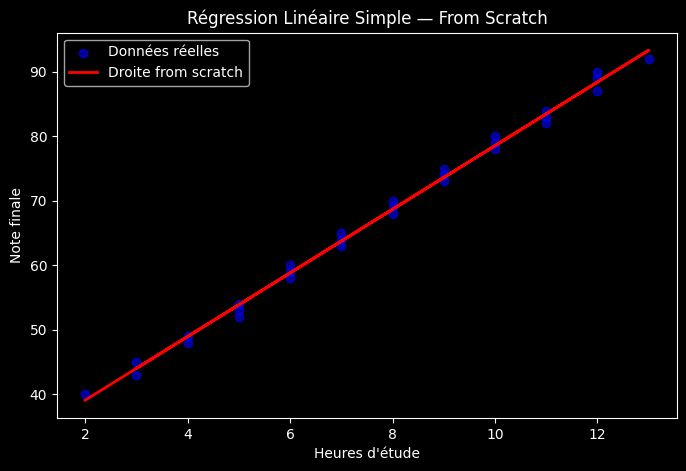

--------------REGRESSION LINEAIRE MULTIPLE-----------------
Shape X_b : (30, 4)

=== Coefficients From Scratch ===
Biais        b  : 38.1789
Heures      a₁  : 3.2604
Motivation  a₂  : 1.1094
Absences    a₃ : -1.0657

=== fonction de cout 
MSE : 0.59


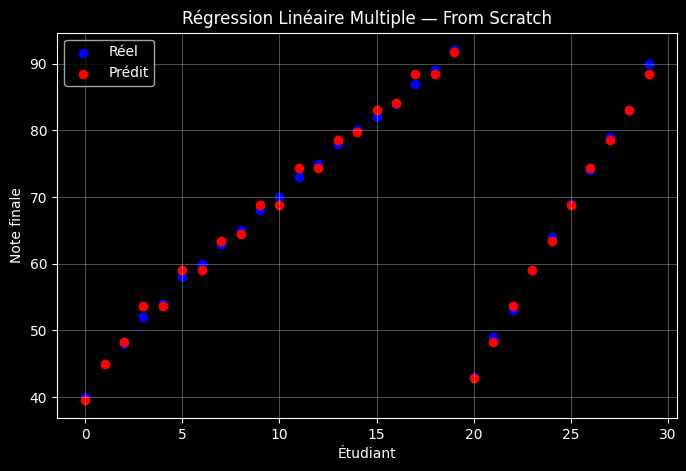

--------------REGRESSION POLYNOMAILE-----------------
Shape X_poly : (30, 3)

=== Coefficients Polynomiaux ===
b   (degré 0) : 28.5591
a₁  (degré 1) : 5.1382
a₂  (degré 2) : -0.0134

=== Évaluation ===
MSE : 0.96


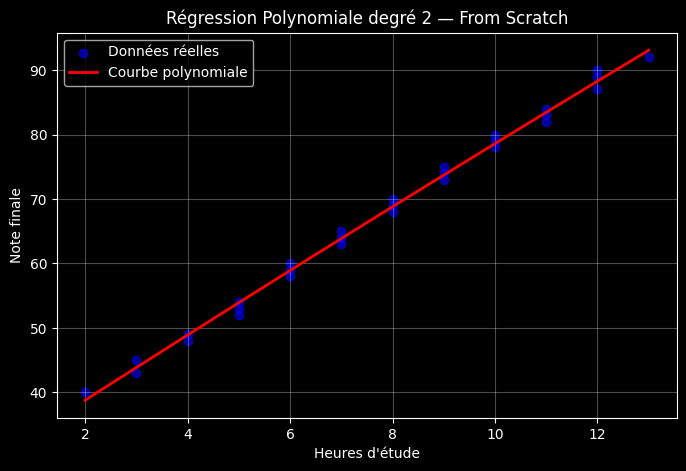

--------------REGRESSION LOGISTIQUE-----------------

=== Résultats ===
Pente a : 0.0835
Biais  b : 0.1846
Formule  : P(réussite) = σ( 0.0835 * x + 0.1846 )
Log Loss : 0.4429


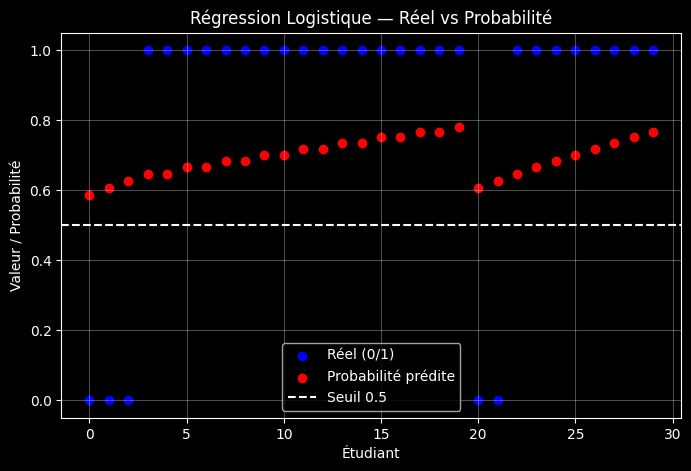

In [1]:
#Version 1 — From Scratch


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#Cette etape est une etape commune entre "Régression Linéaire"et"Régression Linéaire Multiple"et"Régression Polynomiale"

# --------------Charger le datase a partir de notre fichier de donnees 'student_performance.csv' ---------------------
#charger les donnees dans le varaible "df" a l'aide  de Pandas .
df = pd.read_csv('student_performance.csv')

# Vérification 1 — colonnes
print("=== Colonnes ===")
print(df.columns.tolist())

# Vérification 2 — premières lignes
print("\n=== Dimensions ===")
print(df.shape)
#--------------------------------------------






#                -----------------------------------------------------------------
#  1) Régression Linéaire: On va prédire la note finale (Performance_Index) à partir des heures d'étude uniquement (Hours_Studied).
print('--------------REGRESSION LINEAIRE-----------------')

# choisir x et y a partir des colonnes de notre dataset
# x contient les heures des etudes des etudiants :
x=df['Hours_Studied'].values
# y contient la note finale des etudiants :
y=df['Performance_Index'].values

# Etape 1 : Calcule de a et b a partire de la fonction de cout "f(a,b)= (1/2n) · Σ ( yᵢ − ŷᵢ )²"

# Calcule du moyenes pour utiliser dans le calcule de a et b:
x_mean=np.mean(x)
y_mean=np.mean(y)

#  la formule mathematique pour calcule la valeur de a :
# a= Σ(xᵢ − x̄)(yᵢ − ȳ) / Σ(xᵢ − x̄)² (on a trouve cette formule a l'aide de devlopper  a=a - ∂J/∂a)
a= (np.sum((x-x_mean)*(y-y_mean)))/np.sum((x-x_mean)**2)

#  la formule mathematique pour calcule la valeur de b :
# b = ȳ − a · x̄  (on a trouve cette formule a l'aide de devlopper  b=b - ∂J/∂b)
b=y_mean-a*x_mean

print("\n=== Résultats From Scratch ===")
print("Pente a :", round(a, 4))
print("Biais  b :", round(b, 4))
print("Formule  : y =", round(a,4), "* x +", round(b,4))


# Etap 2: Predire et stocker les valeur de preduction dans y_pred
y_pred= a*x + b

# Étape 3 : Calcule de la fonction de cout :
mse= np.mean((y-y_pred)**2)   #coder la formule du fonction de cout f(a,b)= (1/2n) · Σ ( yᵢ − ŷᵢ )²
print("\n=== Résultats de fonction de cout===")
print("MSE :", round(mse, 2))

# Étape 3 :Visualiser ──────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='blue', alpha=0.6, label='Données réelles')
plt.plot(x, y_pred, color='red', linewidth=2, label='Droite from scratch')
plt.xlabel('Heures d\'étude')
plt.ylabel('Note finale')
plt.title('Régression Linéaire Simple — From Scratch')
plt.legend()
plt.show()










#                    ------------------------------------------------------------
#  2) Régression Linéaire Multiple :
print('--------------REGRESSION LINEAIRE MULTIPLE-----------------')


# Choisir x et y a partir des colonnes de notre dataset
# X contient les donnees qu'on va basser pour predure : (les heures des etudes,la motivation,absences)
X = df[['Hours_Studied', 'Motivation', 'Absences']].values  # shape (30, 3)
#  contient la note finale des etudiants (comme le 1er exp de la Régression Linéaire ):
y = df['Performance_Index'].values                         # shape (30,)

# ── Étape 1 : Ajouter la colonne de 1 pour le biais b ────────────
# La matrice X doit avoir une colonne de 1 au début
# Parce que b = b * 1  → le biais est le coefficient de 1
ones = np.ones((X.shape[0], 1))        # colonne de 1 → shape (30, 1)
X_b  = np.hstack([ones, X])            # coller les 1 à gauche → shape (30, 6)

print("Shape X_b :", X_b.shape)        # → (30, 6)

# ── Étape 2 : Formule matricielle θ = (XᵀX)⁻¹ · Xᵀy ─────────────
# on va calculer les Coefficients b ,a₁ ,a₂, a₃ et stocker dans la vecteur theta
theta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y  # coder la formule mathematique θ = (XᵀX)⁻¹ · Xᵀ · y

print("\n=== Coefficients From Scratch ===")     #afficher les coefficients du vecteur theta
print("Biais        b  :", round(theta[0], 4))
print("Heures      a₁  :", round(theta[1], 4))
print("Motivation  a₂  :", round(theta[2], 4))
print("Absences    a₃ :", round(theta[3], 4))

# ── Étape 3 : Prédire les notes et stocker dans le vecteur y_pred
y_pred = X_b.dot(theta)       # shape (30,)

# ── Étape 4 : Calcule la fonction de cout
mse    = np.mean((y- y_pred) ** 2)

print("\n=== fonction de cout ")
print("MSE :", round(mse, 2)) # afficher la valeur de la fonction de cout

# ── Étape 5 : Visualiser ──────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.scatter(range(len(y)), y,      color='blue', label='Réel')
plt.scatter(range(len(y)), y_pred, color='red', label='Prédit')
plt.xlabel('Étudiant')
plt.ylabel('Note finale')
plt.title('Régression Linéaire Multiple — From Scratch')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()








#                       -------------------------------------------------------
#  3) Régression Polynomiale From Scratch:
print('--------------REGRESSION POLYNOMAILE-----------------')

# On utilise une seule variable x (Hours_Studied)

x = df['Hours_Studied'].values     # x contient les heures d'etudes
y = df['Performance_Index'].values

# ── Étape 1 : Créer la matrice polynomiale ────────────────────────
# degré 2 → colonnes : [1, x, x²]
# degré 3 → colonnes : [1, x, x², x³]
degre = 2

X_poly = np.column_stack([x**i for i in range(degre + 1)])
# range(3) → [0, 1, 2] → x⁰=1, x¹=x, x²=x²
# shape → (30, 3)

print("Shape X_poly :", X_poly.shape)   # → (30, 3)

# ── Étape 2 : Formule matricielle (même formule !)
theta = np.linalg.inv(X_poly.T @ X_poly) @ X_poly.T @ y

print("\n=== Coefficients Polynomiaux ===")  # afficher les coefficients du vecteur theta
print("b   (degré 0) :", round(theta[0], 4))
print("a₁  (degré 1) :", round(theta[1], 4))  # a₁ contrôle la pente
print("a₂  (degré 2) :", round(theta[2], 4))  # a₂ contrôle la courbure

# ── Étape 3 : Prédire
y_pred = X_poly.dot(theta) # a l'aide de la matrice polynomiale X_poly et theta (contient les Coefficients ) on va predire la note

# ── Étape 4 : Calcule la fonction de cout
y_mean = np.mean(y)  # calcule le moyenne pour utliser dans le fonction de cout
mse  = np.mean((y - y_pred) ** 2) # calcule la fonction de cout

print("\n=== Évaluation ===")
print("MSE :", round(mse, 2))  # afficher la valeur de la fonction de cout


# ── Étape 5 : Visualiser ──────────────────────────────────────────
x_line  = np.linspace(x.min(), x.max(), 100)
X_line  = np.column_stack([x_line**i for i in range(degre + 1)])
y_line  = X_line.dot(theta)

plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='blue', alpha=0.6, label='Données réelles')
plt.plot(x_line, y_line, color='red', linewidth=2, label='Courbe polynomiale')
plt.xlabel('Heures d\'étude')
plt.ylabel('Note finale')
plt.title('Régression Polynomiale degré 2 — From Scratch')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()







#                       -------------------------------------------------------
#  4) Régression Logistique:
print('--------------REGRESSION LOGISTIQUE-----------------')

# Etape 1:
x=df['Hours_Studied'].values # on mettre les heures des etudes dans x
note =df['Performance_Index'].values # on mettre les notes dans notes
V_F= note >= 50 # on compare la note si la note >50 alors ajouter true sinon false
y= V_F.astype(int) # changer les valeur de V/F en 0 et 1

# Etape 2 : la fonction si  Sigmoïde (on utlise la fct Sigmoïde parce que ]-∞, +∞[ → ]0, 1[ )
# la formule mathematique de la fct est σ(z) = 1 / (1 + e^(-z))
def sigmoide(z):
    return 1 / (1 + np.exp(-z))

# Etape 3 : Calculer a et b avec la formule
x_mean = np.mean(x) #la moyenne de des heures
y_mean = np.mean(y)

a = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean) ** 2) # Calcule  a avec la Formule de a : a = Σ(xᵢ - x̄)(yᵢ - ȳ) / Σ(xᵢ - x̄)²
b = y_mean - a * x_mean # Calcule b avec la Formule de b : b = ȳ - a · x̄
print("\n=== Résultats ===")
print("Pente a :", round(a, 4))
print("Biais  b :", round(b, 4))
print("Formule  : P(réussite) = σ(", round(a, 4), "* x +", round(b, 4), ")")

# Etape 4 : Prédire les probabilités et les classes
z=a * x + b # calcule de z comme la régression linéaire
y_proba= sigmoide(z) #  applique la sigmoïde pour obtenir une probabilité

v=y_proba >= 0.5 # comparer si y_proba >= 0.5 → on prédit 1 (Réussi) sinon 0 (Échoué)
y_classe=v.astype(int) # transforme la probabilité en classe 0 ou 1


# Etape 5: Calcule la fonction de cout :
epsilon = 1e-15
y_proba_safe = np.clip(y_proba, epsilon, 1 - epsilon) #éviter log(0) et log(1)

log_loss = -np.mean(
    y * np.log(y_proba_safe) + (1 - y) * np.log(1 - y_proba_safe)
) #la formule mathematique L = -(1/n) * Σ [ y_i * log(y_pred_i) + (1 - y_i) * log(1 - y_pred_i) ]

print("Log Loss :", round(log_loss, 4))

#Étape 6 : Visualiser
# ── Étape 6 : Visualiser ──────────────────────────────────────────
plt.figure(figsize=(8, 5))# Afficher les vraies classes (0 ou 1)
plt.scatter(range(len(y)), y, color='blue', label='Réel (0/1)')# Afficher les probabilités prédites
plt.scatter(range(len(y)), y_proba, color='red', label='Probabilité prédite')# Ligne seuil 0.5 (décision)
plt.axhline(0.5, linestyle='--', label='Seuil 0.5')

plt.xlabel('Étudiant')
plt.ylabel('Valeur / Probabilité')
plt.title('Régression Logistique — Réel vs Probabilité')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

